In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

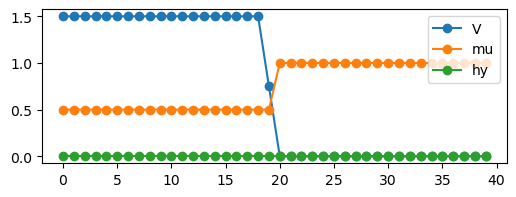

In [5]:
widthD = 20
widthN = 20
X, Y = widthN+widthD, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.5 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[:widthN] = muD

h0 = 0.9 * t
hy = np.zeros_like(mu)


U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthN:] = 0
V[widthN-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [6]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hy=hy)

In [7]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.056685196308499046
Relative error: 56685196308.499054
Average old: 0j
Average: (0.004744485126325899+0j)
F_xplus:
Absolute error: 0.38949505724036554
Relative error: 68886504299.45192
Average old: (0.04871794871794871+0j)
Average: (0.09639201985202886+0j)
F_xmin:
Absolute error: 0.39289827490999935
Relative error: 52161281097.90054
Average old: (0.05128205128205128+0j)
Average: (0.09893430213327155+0j)
F_yplus:
Absolute error: 0.3858876766877731
Relative error: 73963863448.35068
Average old: (-0.05+0j)
Average: (-0.09815986354586374-3.9712409540233115e-18j)
F_ymin:
Absolute error: 0.3858876766877731
Relative error: 73963863448.35068
Average old: (-0.05+0j)
Average: (-0.09815986354586374+3.9712409540233115e-18j)
Fuu_xplus:
Absolute error: 4.603637920703227e-17
Relative error: 4.603637920703227e-05
Average old: 0j
Average: (2.6414592262831676e-19+0j)
Fuu_xmin:
Absolute error: 3.5155795677638174e-17
Relative error: 3.515579567763817e-05
Average old: 0j
Average: (1.20

In [8]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


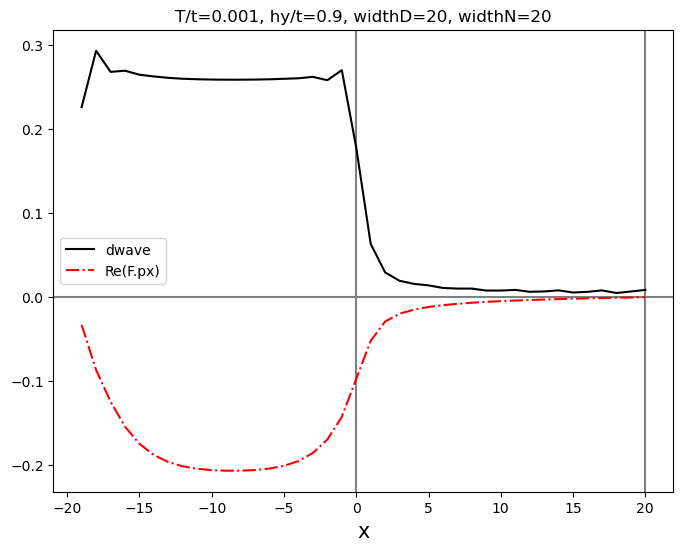

In [10]:
x = np.arange(-widthN, widthD) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthN, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.real(F.px), "-.", label=r"Re(F.px)", color='red')

axs.set_xlabel("x", fontsize=15)
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthD}, widthN={widthN}", )

# axs.set_ylim(None, 0.04)
# axs.set_xlim(-4, 10)
# axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()